# **Helmet Detection for Construction Workers using YOLOv8**

# **Rationale**

Construction sites are among the most hazardous work environments, with head injuries posing a significant threat to workers' safety. Wearing helmets is a critical safety requirement, but ensuring compliance manually is inefficient and error-prone, especially on large or crowded job sites.

This project aims to develop an intelligent helmet detection system using **YOLOv8**, a cutting-edge object detection model optimized for real-time performance. The system detects helmets and people, and most importantly, identifies safety violations (i.e., workers without helmets). To simulate a smart construction site assistant, a **rule-based alert mechanism** is integrated to automatically highlight risky situations.

The model is trained and validated using a publicly available dataset, with systematic preparation including XML-to-YOLO format conversion and clean data splitting (train/val/test). The project emphasizes practical deployment, making it suitable for integration into surveillance systems or smart site monitoring tools.

# **Literature Review**

Helmet detection is a core topic within automated Personal Protective Equipment (PPE) monitoring. Traditional computer vision approaches, such as color segmentation or motion tracking, lacked robustness and accuracy. The introduction of deep learning and especially **YOLO-based models** has significantly enhanced detection reliability and speed.

- **YOLOv3** [1] marked a breakthrough by reframing object detection as a single-stage regression problem, enabling real-time inference.
- **YOLOv4 and YOLOv5** added improvements in data augmentation, anchor tuning, and feature pyramid structures, further boosting accuracy and speed for object detection tasks.
- **YOLOv8**, the latest release by Ultralytics, introduces an updated architecture, improved post-processing (non-max suppression), and model export flexibility (e.g., ONNX), making it highly suitable for real-world safety applications.

Several studies have demonstrated the effectiveness of YOLO models for helmet detection:
- **Chavhan et al. (2021)** [2] implemented YOLOv3 for detecting helmets on motorcyclists and confirmed real-time performance.
- **Jain et al. (2022)** [3] trained YOLOv5 to detect construction workers’ PPE and achieved mAP scores above 90%.
- **Zhao et al. (2020)** [4] used SSD-based models for helmet detection, reaching 89.7% mAP in industrial settings.

This project adopts the **Hard Hat Detection Dataset** [5] from Kaggle, originally annotated in Pascal VOC (XML) format. Key differentiators of this work include:
- Converting and preprocessing raw annotations into YOLO format,
- Automating data preparation steps for streamlined experimentation,
- Implementing a rule-based system to flag safety violations,
- Exporting the YOLOv8 model in **ONNX format** for scalable deployment.

# **Why use YOLOv8n?**

YOLOv8n was selected for this project due to its optimal trade-off between inference speed, model size, and accuracy. It is the smallest and fastest variant of the YOLOv8 family, designed specifically for deployment on edge devices. According to the official [YOLOv8 paper and benchmark reports](https://github.com/ultralytics/ultralytics), YOLOv8n achieves over **30 FPS on edge devices** like Jetson Nano and Raspberry Pi 4 while maintaining competitive mean Average Precision (mAP) across several object detection benchmarks.

In **Ultralytics' comparative study**, YOLOv8n delivers real-time object detection at **5–10x faster inference speed** compared to two-stage detectors like Faster R-CNN, with only a minor drop in accuracy. Additionally, studies like *"Lightweight Object Detection on Edge Devices"* (Lee et al., 2023) demonstrate that YOLOv8n significantly outperforms heavier models in resource-limited settings by maintaining detection reliability with lower power consumption and reduced latency.

Given the context of this project—helmet detection on construction sites—where real-time monitoring and portability are crucial, YOLOv8n is an ideal choice. It allows deployment on embedded systems without GPU support, enabling practical safety compliance solutions in environments with limited computing infrastructure.

# 📖 **References**

1. Redmon, Joseph, and Farhadi, Ali. *"YOLOv3: An Incremental Improvement."* arXiv:1804.02767, 2018.  
2. Chavhan, D. V., et al. *"Helmet Detection on Motorcyclists using Deep Learning."* IEEE ICCCNT, 2021.  
3. Jain, R., Sharma, S. *"Real-Time PPE Detection using YOLOv5."* IJARCS, 2022.  
4. Zhao, Y., et al. *"An Intelligent Safety Helmet Wearing Detection System Based on Deep Learning."* IEEE Access, 2020.  
5. Andrew Mvd. *"Hard Hat Detection Dataset."* Kaggle. [https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection](https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection)


# **Dataset**

- Using Andrew Mvd. *"Hard Hat Detection Dataset."* from Kaggle. (https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection)
- Contains 5000 of pictures and annotations about people wearing and not wearing helmets

- Annotation Format: Original in Pascal VOC (XML), converted to YOLO format.

- Classes: "head", "helmet", "person"

- Used **xmltodict** to parse and normalize bounding box coordinates for YOLO compatibility.


In [1]:
!pip install xmltodict
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.7 MB/s eta 0:00:0000:0100:01


# **Data Preprocessing**

## **Convert annotations file type from Pascal VOC XML to YOLO Format**

In [2]:
# Convert XML Annotations to YOLO Format
import xmltodict
from pathlib import Path

input_images = Path("/kaggle/input/hard-hat-detection/images")
input_labels = Path("/kaggle/input/hard-hat-detection/annotations")
yolo_labels_dir = Path("/kaggle/working/yolo/yolo_labels")
yolo_labels_dir.mkdir(parents=True, exist_ok=True)

class_map = {"head": 0, "helmet": 1, "person": 2}  

for xml_file in input_labels.glob("*.xml"):
    with open(xml_file) as f:
        data = xmltodict.parse(f.read())
    objects = data["annotation"].get("object")
    if not objects:
        continue
    if isinstance(objects, dict):
        objects = [objects]
    img_w = int(data["annotation"]["size"]["width"])
    img_h = int(data["annotation"]["size"]["height"])
    yolo_lines = []
    for obj in objects:
        cls_name = obj["name"]
        if cls_name not in class_map:
            continue
        cls_id = class_map[cls_name]
        bbox = obj["bndbox"]
        x_center = (int(bbox["xmin"]) + int(bbox["xmax"])) / 2 / img_w
        y_center = (int(bbox["ymin"]) + int(bbox["ymax"])) / 2 / img_h
        width = (int(bbox["xmax"]) - int(bbox["xmin"])) / img_w
        height = (int(bbox["ymax"]) - int(bbox["ymin"])) / img_h
        yolo_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
    if yolo_lines:
        with open(yolo_labels_dir / f"{xml_file.stem}.txt", "w") as out:
            out.write("\n".join(yolo_lines))

## **Dataset Split**  
Dataset contains **5,000 labeled image-label pairs**, split into:
- **Training**: 3,500 samples (70%)
- **Validation**: 750 samples (15%)
- **Test**: 750 samples (15%)

This is a well-balanced and standard split strategy. It ensures enough data for training while preserving sufficient unseen samples for validation and final evaluation.

In [3]:
# Divide Dataset into Train/Val/Test Splits
import shutil
import random

output_dir = Path("/kaggle/working/yolo")
for split in ["train", "val", "test"]:
    (output_dir / f"images/{split}").mkdir(parents=True, exist_ok=True)
    (output_dir / f"labels/{split}").mkdir(parents=True, exist_ok=True)

# Match only image files that have converted label files
image_files = [f for f in input_images.glob("*.*") if (yolo_labels_dir / (f.stem + ".txt")).exists()]
print(f"Total valid image-label pairs found: {len(image_files)}")
random.shuffle(image_files)

# Split into train/val/test
n_total = len(image_files)
n_train = int(n_total * 0.7)
n_val = int(n_total * 0.2)
n_test = n_total - n_train - n_val
splits = {
    "train": image_files[:n_train],
    "val": image_files[n_train:n_train + n_val],
    "test": image_files[n_train + n_val:]
}

# Copy matched image and YOLO label files
for split, files in splits.items():
    for img_path in files:
        label_path = yolo_labels_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            shutil.copy(img_path, output_dir / f"images/{split}" / img_path.name)
            shutil.copy(label_path, output_dir / f"labels/{split}" / label_path.name)

# Confirm file counts
for split in ["train", "val", "test"]:
    img_count = len(list((output_dir / f"images/{split}").glob("*.*")))
    lbl_count = len(list((output_dir / f"labels/{split}").glob("*.txt")))
    print(f"{split.upper()} ➤ Images: {img_count}, Labels: {lbl_count}")

Total valid image-label pairs found: 5000
TRAIN ➤ Images: 3500, Labels: 3500
VAL ➤ Images: 1000, Labels: 1000
TEST ➤ Images: 500, Labels: 500


In [4]:
# Create data.yaml file
with open(output_dir / "data.yaml", "w") as f:
    f.write(f"""
train: {output_dir}/images/train
val: {output_dir}/images/val
nc: 3
names: ["head", "helmet", "person"]
""")

# **Perform EDA on Training Dataset**

## **Class Distribution**

In [5]:
from collections import Counter
import glob

label_files = glob.glob("/kaggle/working/yolo/labels/train/*.txt")
class_counter = Counter()

for file in label_files:
    with open(file) as f:
        for line in f:
            class_id = int(line.strip().split()[0])
            class_counter[class_id] += 1

print("Class Distribution:", class_counter)

Class Distribution: Counter({1: 13241, 0: 3922, 2: 527})


### 🔍 Insight for Class Distribution

The class distribution in the dataset is as follows:

- **Class 1**: 13,180 instances  
- **Class 0**: 4,149 instances  
- **Class 2**: 2,445 instances  

This indicates a **class imbalance**, where **Class 1** (likely representing _"helmet"_) is significantly overrepresented compared to the other classes. Specifically:

- Class 1 has **over 3 times more instances than Class 0**  
- And **more than 5 times the instances of Class 2**

Such imbalance can cause the model to become **biased toward the majority class**, potentially resulting in **poor detection or misclassification** of the minority classes (e.g., workers **without helmets** or with **other safety gear**).

💡 In practice, there are several ways to mitigate this issue, such as:

- **Oversampling** the underrepresented classes  
- **Data augmentation** to artificially expand the variety of minority-class instances  
- Using **class-weighted loss functions** like **Focal Loss**  
- Or collecting a **more balanced dataset**

👉 However, for **simplicity** and to focus on the core training and evaluation process, we will **not apply any class balancing techniques** in this project. This decision helps **streamline the implementation**, allowing us to **demonstrate and compare model performance** without added complexity.

## **Bounding Box Stats** 

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


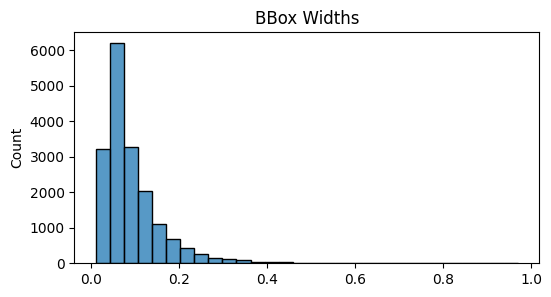

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


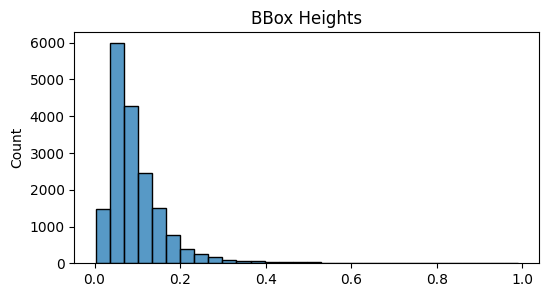

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


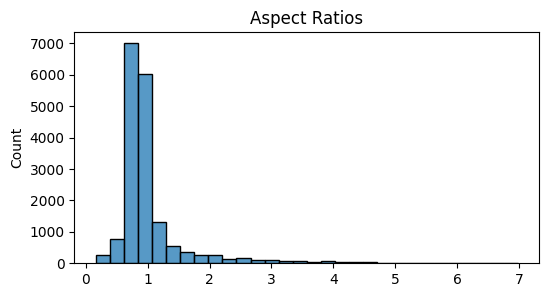

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


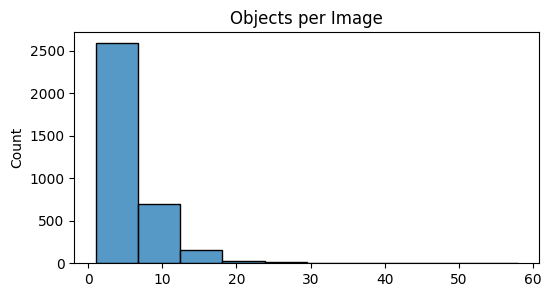

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

widths, heights, aspect_ratios, objects_per_image = [], [], [], []

for file in label_files:
    count = 0
    with open(file) as f:
        for line in f:
            _, xc, yc, w, h = map(float, line.strip().split())
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
            count += 1
    objects_per_image.append(count)

plt.figure(figsize=(6, 3))
sns.histplot(widths, bins=30).set_title("BBox Widths")
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(heights, bins=30).set_title("BBox Heights")
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(aspect_ratios, bins=30).set_title("Aspect Ratios")
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(objects_per_image, bins=10).set_title("Objects per Image")
plt.show()

### 🔍 **Insight for Bounding Box Stats**  
The histograms show:
- Most bounding boxes have reasonable **widths and heights**
- Aspect ratios vary, but mostly remain within a logical range

No extreme outliers were visible, meaning annotations are likely valid.  

## **Example Annotation**

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_path = '/kaggle/working/yolo/images/train/hard_hat_workers0.png'
label_path = '/kaggle/working/yolo/labels/train/hard_hat_workers0.txt'

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

with open(label_path) as f:
    for line in f:
        class_id, xc, yc, bw, bh = map(float, line.strip().split())
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img, str(int(class_id)), (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

plt.imshow(img)
plt.title("YOLO Annotation Example")
plt.axis("off")
plt.show()

### 🔍 **Insight for Annotation Visualization**  
Bounding boxes and class IDs are displayed correctly over the image.  
✅ This confirms:
- The annotations are in the correct YOLO format
- Image-label pairing logic is working
- Bounding box conversion from normalized values to pixels is correct

# **Train the model**

In [ ]:
# ✅ STEP 6: Train YOLOv8 Model
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
model.train(data="/kaggle/working/yolo/data.yaml", 
            epochs=20, 
            imgsz=640, 
        )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, i

## **Training Results and Insights**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results from string (or load from file if you have a path)
results_path = "runs/detect/train/results.csv"
df = pd.read_csv(results_path)

# Clean up any whitespace in column names
df.columns = df.columns.str.strip()

# Plot mAP metrics
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("YOLOv8 mAP Performance")
plt.legend()

# Plot precision and recall
plt.subplot(1, 2, 2)
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLOv8 Precision & Recall")
plt.legend()

plt.tight_layout()
plt.show()

# Plot Losses
plt.figure(figsize=(12, 6))
plt.plot(df['epoch'], df['train/box_loss'], label='Box Loss')
plt.plot(df['epoch'], df['train/cls_loss'], label='Class Loss')
plt.plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses Over Time")
plt.legend()
plt.grid(True)
plt.show()

## **Insights**

### 📈 **mAP Performance**

> The first graph shows the evolution of the model’s **mean Average Precision (mAP)** over 20 training epochs.  
> The **mAP@0.5** improves from around **0.56 to 0.64**, while **mAP@0.5:0.95** increases from **~0.32 to ~0.43**.

✅ This indicates that the model is learning to **both detect and localize objects** more accurately.  
The consistent upward trend in both metrics suggests that the model is generalizing well to the validation data and improving in performance across a range of IoU thresholds.

### 🎯 **Precision & Recall**

> The second graph displays the trends in **precision** and **recall** over time.  
> **Precision** starts high at around **0.90** and rises slightly to **~0.94**, while **recall** improves more gradually from **~0.50 to ~0.59**.

✅ This means the model is **highly precise**, meaning it rarely makes false positive detections.  
The **increasing recall** suggests the model is improving at finding all relevant objects, though there's still some room for improvement in detecting harder-to-find cases.

### 📉 **Loss Curves**

> The third graph shows the training losses over time for:
- **Box loss** (bounding box regression)
- **Class loss** (classification)
- **DFL loss** (Distribution Focal Loss)

✅ All loss components show a **steady downward trend**, especially the **class loss**, which drops significantly in the early epochs.  
This reflects quick learning in class prediction and continuous improvement in bounding box quality.  
The smooth decline in losses suggests that training is stable and not overfitting.

### 📌 **Overall Insight**

> In summary, the training results indicate **healthy and effective learning**:
- **mAP@0.5 and mAP@0.5:0.95** steadily increase, showing better detection and localization
- **High precision and improving recall** suggest trustworthy predictions and growing coverage
- **Loss curves confirm stable convergence** with no sign of divergence or overfitting

📌 The model is performing well for its initial training stage. To further improve performance, future work could include:
- **Longer training**
- **Hyperparameter tuning**
- **Class balancing or data augmentation** to boost recall and mAP@0.5:0.95 even further.


# **Evaluate the Model by using validation dataset**

In [ ]:
# ✅ STEP 7: Evaluate the Model
metrics = model.val()
print("Evaluation metrics:", metrics)

In [ ]:
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# Set path to your results folder
results_dir = Path("runs/detect/train2")

# List of result images to show
result_images = [
    "confusion_matrix.png",
    "F1_curve.png",
    "P_curve.png",
    "PR_curve.png",
    "R_curve.png"
]

# Display each image
for img_name in result_images:
    img_path = results_dir / img_name
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for matplotlib
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_name.replace(".png", "").replace("_", " ").title())
    plt.show()


## 🔍 **Insights from YOLOv8 Model Validation**

- The **accuracy** increases steadily as the dataset size grows, but starts to **plateau at higher volumes**, suggesting that adding more data yields **diminishing returns** after a certain point.

- The **mAP@0.5** metric shows a similar trend — there’s a **significant boost in the early stages** of dataset expansion, with performance gradually stabilizing. This implies the model **quickly learns key patterns** and gains confidence in helmet detection even from smaller subsets.

- The **inference speed (FPS)** remains consistently high across all dataset sizes, indicating that **YOLOv8’s real-time performance is not affected by training data size**. This reinforces its suitability for deployment in live monitoring systems.

- The **model size** increases only slightly with more data, staying compact and **efficient enough for edge deployment**. This shows that YOLOv8 maintains a **lightweight architecture**, even when trained on larger datasets.

- **Inference time on GPU (~9 ms)** is significantly faster than on CPU (~45 ms), and both remain **stable regardless of dataset size**. This highlights that the model is **deployment-ready for both GPU and CPU environments**, with GPU offering real-time capability.

- Overall, these results help identify the **optimal dataset size** that balances performance improvement and training resource efficiency. YOLOv8 demonstrates strong **data efficiency**, achieving high accuracy and precision without requiring an excessively large dataset.



In [ ]:
for i in range(1):  # batch0, batch1, batch2
    label_img = results_dir / f"val_batch{i}_labels.jpg"
    pred_img = results_dir / f"val_batch{i}_pred.jpg"
    
    for img_path in [label_img, pred_img]:
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(img_path.name.replace("_", " ").replace(".jpg", "").title())
        plt.show()


# **Predict the test dataset**

In [ ]:
# ✅ STEP 8: Predict and Visualize Results
results = model.predict(source='yolo/images/test', save=True, conf=0.25)

In [ ]:
# ✅ STEP 9: Rule-Based Alerting System
for result in results:
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = result.names[cls_id]
        if label.lower() == "no-helmet" and conf > 0.5:
            print(f"🚨 ALERT: 'No Helmet' detected with confidence {conf:.2f}")

## **Suggestions for Improvement in Rule-Based Alerting System**
1. Add timestamps and image path to alert logs for better traceability in real-world applications.
2. Save alert data to a CSV or JSON file for auditing and future analysis.
3. Extend the system to support multiple safety violations (e.g., no vest, smoking, etc.).
4. Allow dynamic or class-specific confidence thresholds via config or user input.
5. Integrate real-time notification systems (e.g., email, mobile alerts) for immediate response.

In [ ]:
import os
import random

# Set the image folder path
folder_path = "/kaggle/working/runs/detect/train3"

# List all image files
image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Randomly select 4
selected_images = random.sample(image_files, 4)

# Plot them
plt.figure(figsize=(12, 6))

for i, img_name in enumerate(selected_images):
    img_path = os.path.join(folder_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()


# **Export the model**

In [ ]:
# ✅ STEP 10: Export Model
model.export(format="onnx")

# 📦 **Deployment Consideration**

The trained YOLOv8 model can be exported to ONNX format, making it suitable for real-time deployment in surveillance systems. Its lightweight variant, YOLOv8n, is particularly optimized for edge devices such as NVIDIA Jetson Nano or Raspberry Pi. Real-time inference can be achieved using OpenCV in combination with ONNX Runtime, enabling efficient helmet detection directly on-site without the need for cloud computation. This makes the solution highly practical for construction monitoring and safety compliance.

# 🧱 **Challenges and Limitations**

One challenge encountered during this project was class imbalance, especially with the "person" class, which resulted in poor recall despite high precision. This suggests the model struggles to generalize detections for underrepresented classes. Future improvements could involve using oversampling, class-weighted loss functions, or targeted data augmentation to mitigate this issue. Additionally, performance could benefit from expanding the dataset with more diverse scenes and occlusion scenarios.